In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
%matplotlib inline

In [21]:
nadia = cv2.imread('./DATA/Nadia_Murad.jpg',0)
denis = cv2.imread('./DATA/Denis_Mukwege.jpg',0)
solvay = cv2.imread('./DATA/solvay_conference.jpg',0)
it_ns = cv2.imread('./DATA/it-ns2.png',cv2.IMREAD_GRAYSCALE)

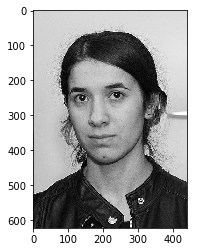

In [22]:
plt.imshow(nadia,cmap='gray')

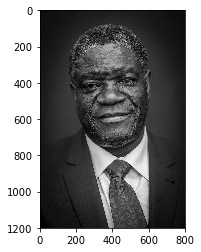

In [23]:
plt.imshow(denis,cmap='gray')

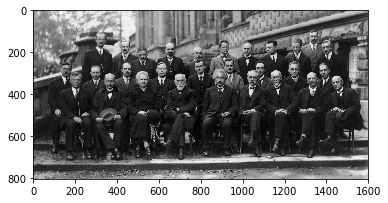

In [24]:
plt.imshow(solvay,cmap='gray')

In [25]:
face_cascade = cv2.CascadeClassifier('./DATA/haarcascades/haarcascade_frontalface_default.xml')

In [26]:
def detect_face(img):
    
  
    face_img = img.copy()
  
    face_rects = face_cascade.detectMultiScale(face_img) 
    
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
    return face_img

In [27]:
result = detect_face(it_ns)

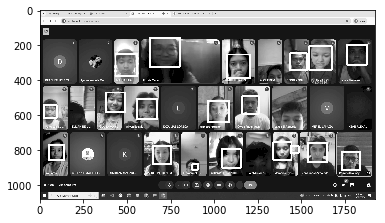

In [28]:
plt.imshow(result,cmap='gray')

In [29]:
def adj_detect_face(img):
    
    face_img = img.copy()
  
    face_rects = face_cascade.detectMultiScale(face_img,scaleFactor=1.2, minNeighbors=5) 
    
    for (x,y,w,h) in face_rects: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
        
    return face_img

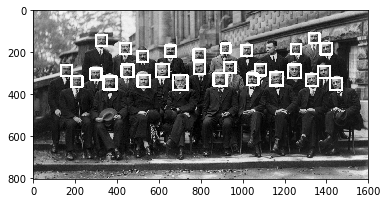

In [30]:
# Doesn't detect the side face.
result = adj_detect_face(solvay)
plt.imshow(result,cmap='gray')

In [31]:
eye_cascade = cv2.CascadeClassifier('./DATA/haarcascades/haarcascade_eye.xml')

In [32]:
def detect_eyes(img):
    
    face_img = img.copy()
  
    eyes = eye_cascade.detectMultiScale(face_img) 
    
    
    for (x,y,w,h) in eyes: 
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10) 
        
    return face_img
    

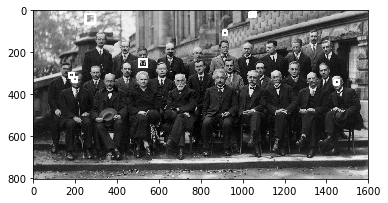

In [36]:
result = detect_eyes(solvay)
plt.imshow(result,cmap='gray')

In [38]:
cap = cv2.VideoCapture(0) 

while True: 
    
    ret, frame = cap.read(0) 
     
    frame = detect_face(frame)
 
    cv2.imshow('Video Face Detection', frame) 
 
    c = cv2.waitKey(1) 
    if c == 27: 
        break 
        
cap.release() 
cv2.destroyAllWindows()